In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import copy

# 1. Зашумить изображение при помощи шума гаусса, постоянного шума

In [3]:
image = cv2.imread('img.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

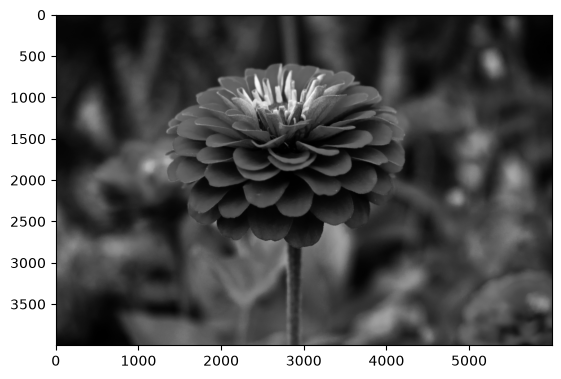

In [4]:
plt.imshow(image_gray, cmap="gray")

In [5]:
# Шум Гаусса
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[  0,  16,   0, ..., 150,  56,   0],
       [ 86,   0, 238, ...,   0,   0,  36],
       [ 39, 106,   0, ...,   0, 194,   0],
       ...,
       [  0,   0,  36, ...,   0,  35, 139],
       [  0,   0,   0, ...,   0, 106,   0],
       [102,   0,   0, ...,   0,  67,   0]],
      shape=(4000, 6000), dtype=uint8)

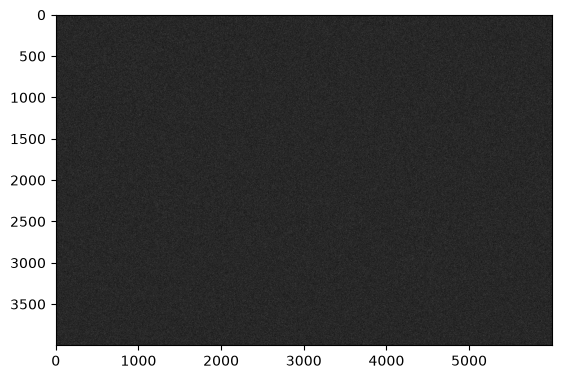

In [40]:
plt.imshow(noise_gauss, cmap="gray")

In [6]:
image_noise_gauss = cv2.add(image_gray, noise_gauss)

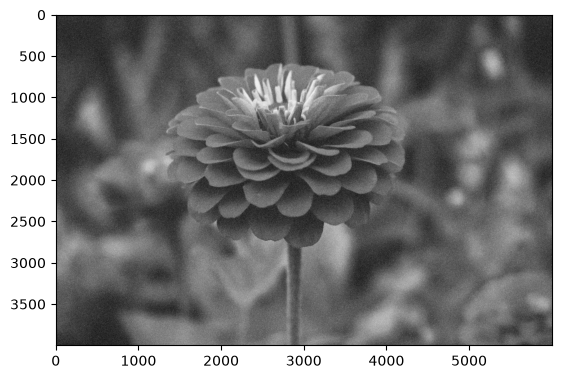

In [7]:
plt.imshow(image_noise_gauss, cmap="gray")

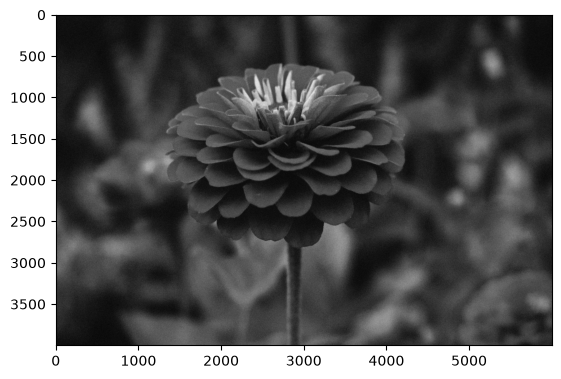

In [11]:
# постоянный шум
image_noise = copy.deepcopy(image_gray)
low, high = -50, 50
noise_uniform = np.random.uniform(low, high, image_noise.shape).astype(np.float32)
image_uniform = np.clip(
    image_noise.astype(np.float32) + noise_uniform, 0, 255
).astype(np.uint8)
plt.imshow(image_uniform, cmap="gray")

# 2. Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.

In [10]:
from skimage.metrics import structural_similarity, mean_squared_error
def photo_comparison(image_src, image):
    (ssim, diff) = structural_similarity(image_src, image, full=True)
    mse = mean_squared_error(image_src, image)
    print(f"SSIM: {ssim} MSE: {mse}")

In [12]:
photo_comparison(image_gray, image_noise_gauss)
photo_comparison(image_gray, image_uniform)
photo_comparison(image_noise_gauss, image_uniform)

SSIM: 0.025890101157439064 MSE: 4498.495616958333
SSIM: 0.103042129771666 MSE: 742.8369102916666
SSIM: 0.02031080737009975 MSE: 5145.951956083333


In [46]:
image_gauss_median_3 = cv2.medianBlur(image_noise_gauss, 3)
image_gauss_median_5 = cv2.medianBlur(image_noise_gauss, 5)
image_gauss_nlm_10 = cv2.fastNlMeansDenoising(image_noise_gauss, h=10)
image_gauss_nlm_20 = cv2.fastNlMeansDenoising(image_noise_gauss, h=20)
image_gauss_bilat_1 = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
image_gauss_bilat_2 = cv2.bilateralFilter(image_noise_gauss, 5, 50, 50)

In [47]:
photo_comparison(image_gray, image_gauss_median_3)
photo_comparison(image_gray, image_gauss_median_5)
photo_comparison(image_gray, image_gauss_nlm_10)
photo_comparison(image_gray, image_gauss_nlm_20)
photo_comparison(image_gray, image_gauss_bilat_1)
photo_comparison(image_gray, image_gauss_bilat_2)


SSIM: 0.15370110818000268 MSE: 843.748424125
SSIM: 0.3662160482407186 MSE: 332.70441495833336
SSIM: 0.026093698644567884 MSE: 4499.07773925
SSIM: 0.028914214465221362 MSE: 4486.986367625
SSIM: 0.10444690919591168 MSE: 1786.798545375
SSIM: 0.042658151572038026 MSE: 3048.6124391666667


In [13]:
image_sp_median_3 = cv2.medianBlur(image_uniform, 3)
image_sp_median_5 = cv2.medianBlur(image_uniform, 5)
image_sp_nlm_10 = cv2.fastNlMeansDenoising(image_uniform, h=10)
image_sp_nlm_20 = cv2.fastNlMeansDenoising(image_uniform, h=20)
image_sp_bilat_1 = cv2.bilateralFilter(image_uniform, 9, 75, 75)
image_sp_bilat_2 = cv2.bilateralFilter(image_uniform, 5, 50, 50)


In [14]:
photo_comparison(image_gray, image_sp_median_3)
photo_comparison(image_gray, image_sp_median_5)
photo_comparison(image_gray, image_sp_nlm_10)
photo_comparison(image_gray, image_sp_nlm_20)
photo_comparison(image_gray, image_sp_bilat_1)
photo_comparison(image_gray, image_sp_bilat_2)


SSIM: 0.26839745748661276 MSE: 220.343036625
SSIM: 0.4611119022754917 MSE: 100.905461375
SSIM: 0.11101177275639779 MSE: 727.2517275416667
SSIM: 0.6764733292782092 MSE: 44.247665
SSIM: 0.671558254605803 MSE: 47.62349991666667
SSIM: 0.39465185111193574 MSE: 132.3516095


# Лучшие результаты

Для шума Гаусса - медианный фильтр с параметром 5: SSIM: 0.3663 MSE: 332.15

Для постоянного шума - нелокальных средних с параметром 20: SSIM: 0.676 MSE: 44.247